In [28]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [29]:
train = pd.read_csv("../dataset/train.csv")
test = pd.read_csv("../dataset/test.csv")

In [30]:
train["hour"] = (
    train["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

for i in [4,5,6]:
    train[f"geo{i}"] = (
        train["geohash"]
        .str[:i]
    )

    test[f"geo{i}"] = (
        test["geohash"]
        .str[:i]
    )

1. Geo5 Mean Demand

In [31]:
geo5_stats = (
    train.groupby("geo5")["demand"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "max"
    ])
)

geo5_stats.head()

,count,mean,std,min,max
geo5,,,,,
qp02y,45,0.030092,0.021402,1.886676e-03,0.111003
qp02z,1389,0.143467,0.169379,7.981559e-07,0.964628
qp03j,551,0.026123,0.015038,2.811404e-04,0.084580
qp03m,2023,0.040445,0.058689,4.747904e-05,0.609067
qp03n,751,0.066674,0.047337,1.189018e-05,0.228520


In [32]:
geo5_stats.sort_values(
    "mean",
    ascending=False
).head(20)

,count,mean,std,min,max
geo5,,,,,
qp09d,2348,0.270892,0.306452,1.077777e-04,1.000000
qp09w,97,0.257290,0.217886,1.907718e-03,0.804199
qp096,2389,0.211010,0.268272,1.944327e-04,1.000000
qp03x,3275,0.177182,0.187513,9.987729e-05,1.000000
qp09e,1995,0.156548,0.245714,1.391026e-05,1.000000
qp02z,1389,0.143467,0.169379,7.981559e-07,0.964628
qp090,1778,0.134398,0.150755,2.208096e-05,0.843469
qp03w,3086,0.133275,0.169154,8.778930e-05,1.000000
qp098,2222,0.119912,0.127814,4.585962e-05,0.868056


In [33]:
geo5_stats.sort_values(
    "mean"
).head(20)

,count,mean,std,min,max
geo5,,,,,
qp09n,31,0.011380,0.009428,0.000139,0.039413
qp09q,78,0.012065,0.011759,0.000072,0.050622
qp08u,44,0.013371,0.009597,0.000384,0.032476
qp08f,172,0.015405,0.016229,0.000047,0.090541
qp03v,127,0.017201,0.016271,0.000053,0.073165
qp06n,610,0.018213,0.017783,0.000010,0.083404
qp0dn,87,0.018916,0.019240,0.000366,0.091209
qp0d0,1120,0.023648,0.026143,0.000010,0.188566
qp03j,551,0.026123,0.015038,0.000281,0.084580


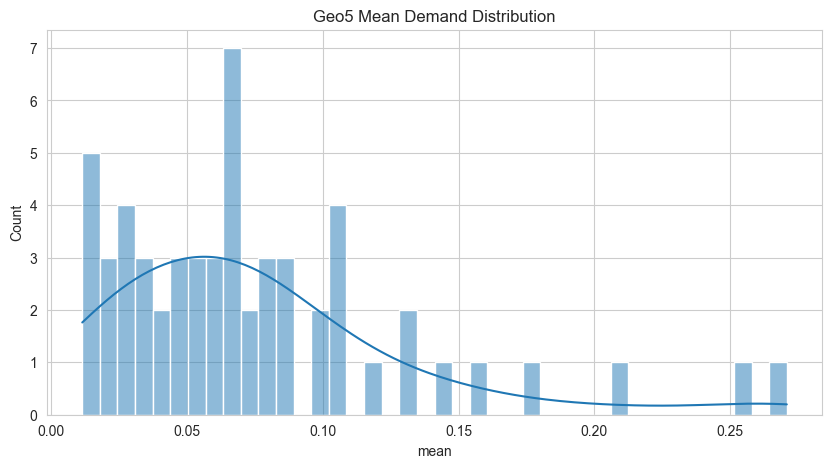

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    geo5_stats["mean"],
    bins=40,
    kde=True
)

plt.title(
    "Geo5 Mean Demand Distribution"
)

plt.show()

In [35]:
print(
    "Geo5 Mean Std:",
    geo5_stats["mean"].std()
)

Geo5 Mean Std: 0.056406230044062776


Interpretation:

Large std means location itself explains demand.

2. Geo6 Mean Demand

In [36]:
geo6_stats = (
    train.groupby("geo6")["demand"]
    .agg([
        "count",
        "mean",
        "std"
    ])
)

geo6_stats.head()

,count,mean,std
geo6,,,
qp02yc,12,0.018498,0.012374
qp02yf,1,0.029433,NaN
qp02yy,2,0.002902,0.001435
qp02yz,30,0.036564,0.022065
qp02z1,33,0.040048,0.030124


In [37]:
print(
    "Geo6 Mean Std:",
    geo6_stats["mean"].std()
)

Geo6 Mean Std: 0.09986115803568335


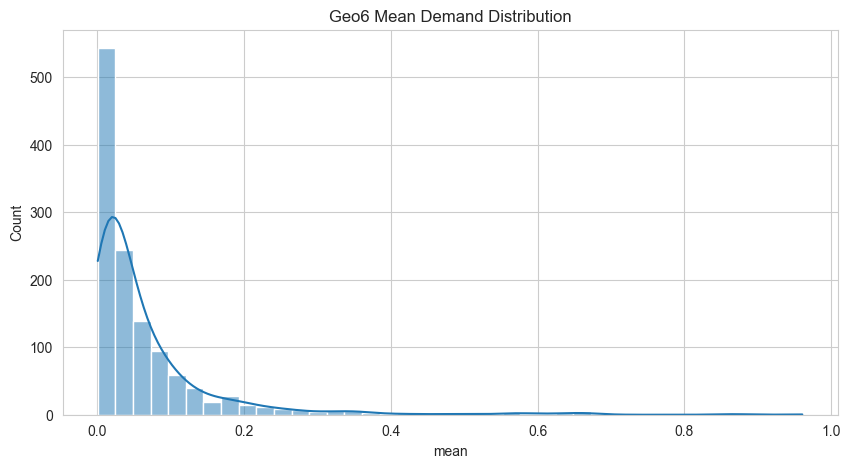

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    geo6_stats["mean"],
    bins=40,
    kde=True
)

plt.title(
    "Geo6 Mean Demand Distribution"
)

plt.show()

3. Hour Mean Demand

In [39]:
hour_stats = (
    train.groupby("hour")["demand"]
    .agg([
        "count",
        "mean",
        "std"
    ])
)

hour_stats

,count,mean,std
hour,,,
0,6338,0.083369,0.122252
1,6871,0.089793,0.126183
2,4455,0.087368,0.120569
3,3595,0.091329,0.127422
4,3683,0.101678,0.142908
5,3621,0.104368,0.146397
6,3665,0.103913,0.148054
7,3569,0.106198,0.152324
8,3507,0.106149,0.156256


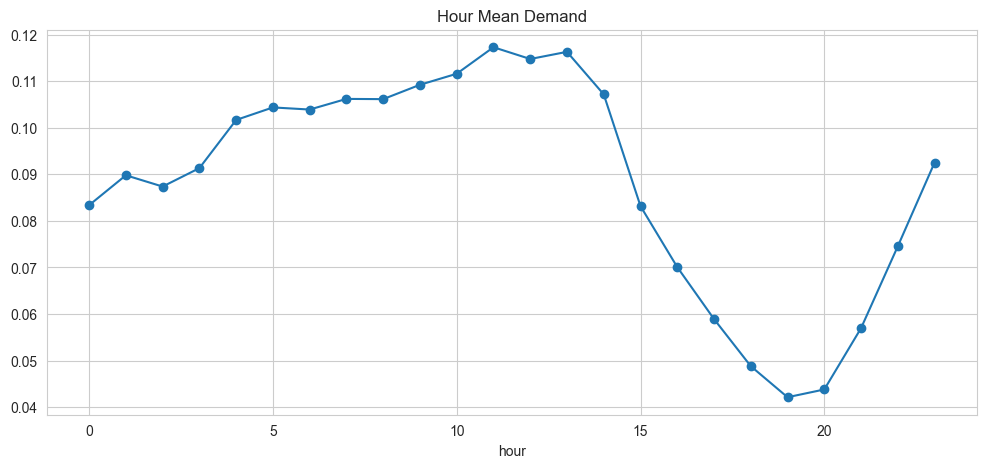

In [40]:
plt.figure(figsize=(12,5))

hour_stats["mean"].plot(
    marker="o"
)

plt.title(
    "Hour Mean Demand"
)

plt.show()

In [41]:
print(
    "Hour Mean Std:",
    hour_stats["mean"].std()
)

Hour Mean Std: 0.023873357674299833


4. Geo5 × Hour Demand

In [42]:
geo5_hour = (
    train.groupby(
        ["geo5","hour"]
    )["demand"]
    .mean()
)

geo5_hour.head()

geo5   hour
qp02y  1       0.005397
       2       0.017868
       3       0.018810
       4       0.018562
       5       0.043532
Name: demand, dtype: float64

In [43]:
geo5_hour_df = (
    train.pivot_table(
        values="demand",
        index="geo5",
        columns="hour",
        aggfunc="mean"
    )
)

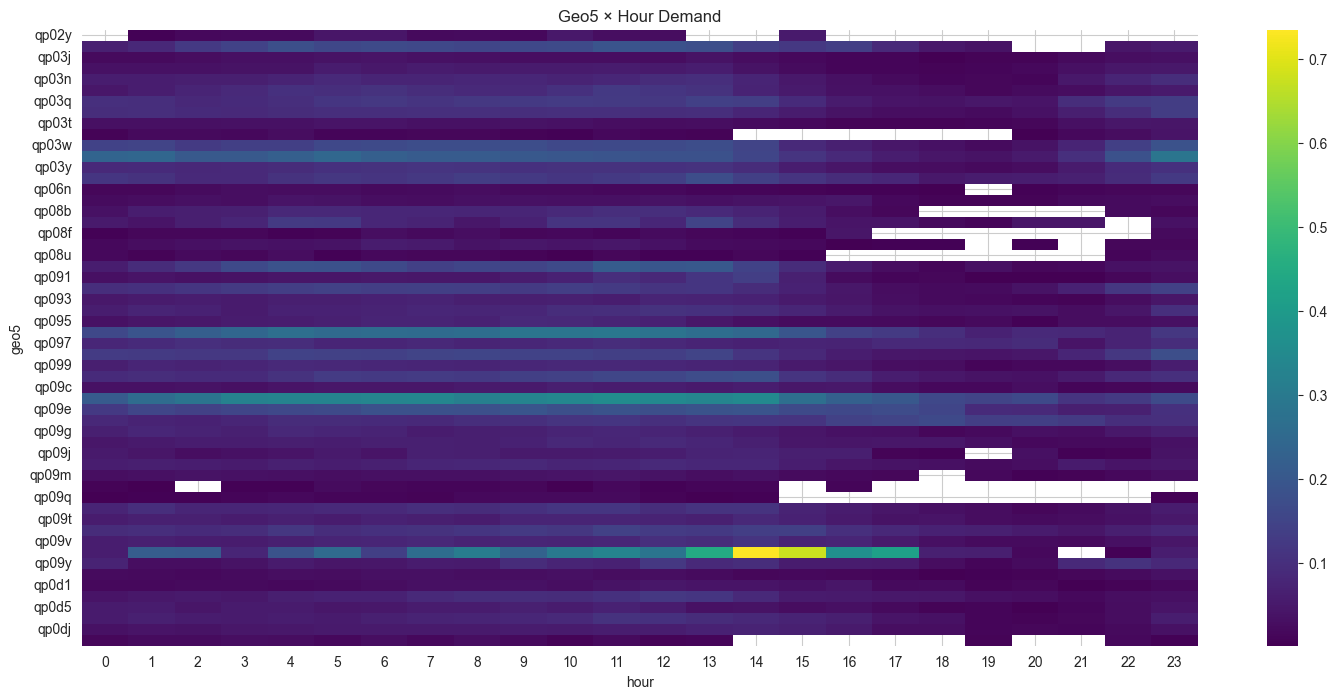

In [44]:
plt.figure(figsize=(18,8))

sns.heatmap(
    geo5_hour_df,
    cmap="viridis"
)

plt.title(
    "Geo5 × Hour Demand"
)

plt.show()

5. Variance Explained

In [45]:
overall_var = train["demand"].var()

print(
    "Overall Variance:",
    overall_var
)

Overall Variance: 0.02021814579454786


In [46]:
geo5_var = (
    train.groupby(
        "geo5"
    )["demand"]
    .mean()
    .var()
)

print(
    "Geo5 Variance:",
    geo5_var
)

Geo5 Variance: 0.0031816627877837298


In [47]:
hour_var = (
    train.groupby(
        "hour"
    )["demand"]
    .mean()
    .var()
)

print(
    "Hour Variance:",
    hour_var
)

Hour Variance: 0.0005699372066450506


In [48]:
geo5_hour_var = (
    train.groupby(
        ["geo5","hour"]
    )["demand"]
    .mean()
    .var()
)

print(
    "Geo5-Hour Variance:",
    geo5_hour_var
)

Geo5-Hour Variance: 0.004534006225687022


In [49]:
print(
    "Geo5 Signal:",
    round(
        geo5_var / overall_var,
        4
    )
)

print(
    "Hour Signal:",
    round(
        hour_var / overall_var,
        4
    )
)

print(
    "Geo5-Hour Signal:",
    round(
        geo5_hour_var / overall_var,
        4
    )
)

Geo5 Signal: 0.1574
Hour Signal: 0.0282
Geo5-Hour Signal: 0.2243


6. RoadType × Geo5

In [50]:
road_geo = (
    train.pivot_table(
        values="demand",
        index="RoadType",
        columns="geo5",
        aggfunc="mean"
    )
)

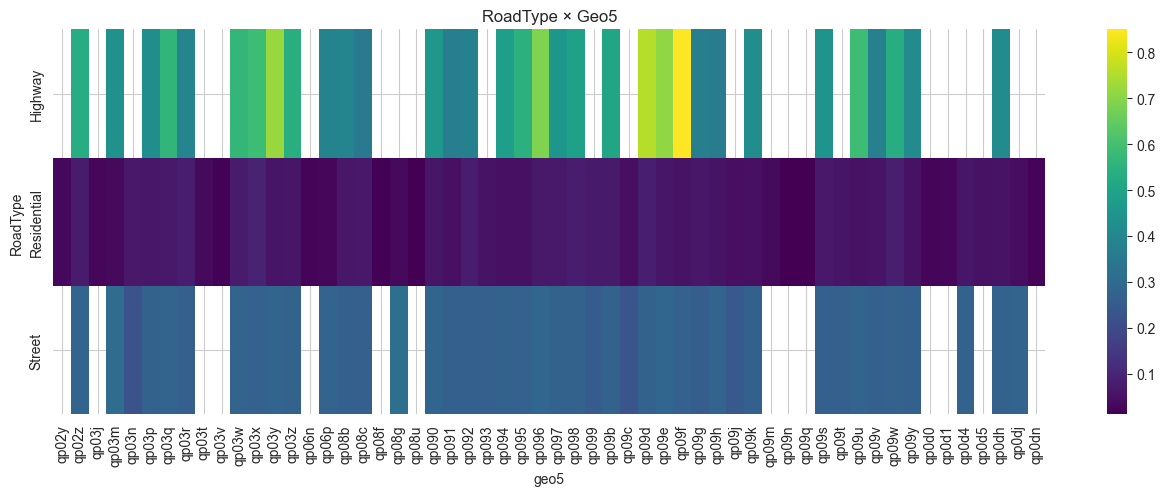

In [51]:
plt.figure(figsize=(16,5))

sns.heatmap(
    road_geo,
    cmap="viridis"
)

plt.title(
    "RoadType × Geo5"
)

plt.show()

7. Geo5 Frequency

In [52]:
geo5_freq = (
    train["geo5"]
    .value_counts()
)

In [53]:
geo5_freq.describe()

count      56.000000
mean     1380.339286
std       894.328865
min        31.000000
25%       613.000000
50%      1277.500000
75%      2029.500000
max      3275.000000
Name: count, dtype: float64

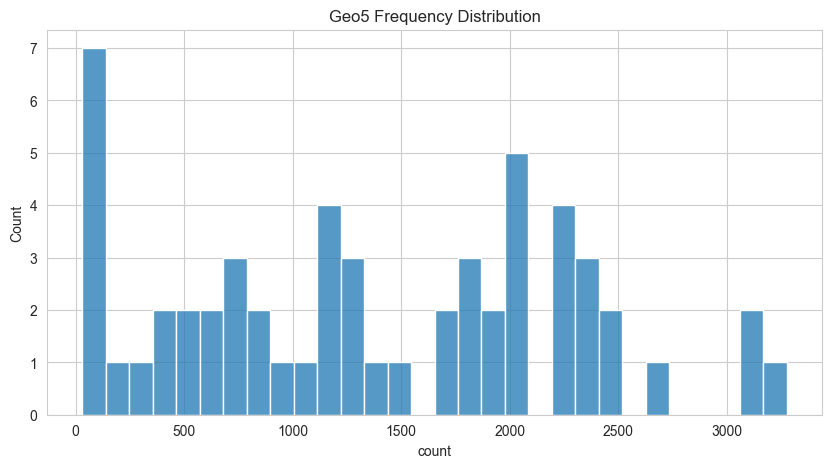

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    geo5_freq,
    bins=30
)

plt.title(
    "Geo5 Frequency Distribution"
)

plt.show()